In [17]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("test.csv")

In [18]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [22]:
# 3. Unique values and missing values for each column
for col in df.columns:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique()[:10], "...")  # show first 10 unique values
    print("Number of unique values:", df[col].nunique())
    print("Missing values:", df[col].isna().sum())


Column: PassengerId
Unique values: [892 893 894 895 896 897 898 899 900 901] ...
Number of unique values: 418
Missing values: 0

Column: Pclass
Unique values: [3 2 1] ...
Number of unique values: 3
Missing values: 0

Column: Name
Unique values: ['Kelly, Mr. James' 'Wilkes, Mrs. James (Ellen Needs)'
 'Myles, Mr. Thomas Francis' 'Wirz, Mr. Albert'
 'Hirvonen, Mrs. Alexander (Helga E Lindqvist)'
 'Svensson, Mr. Johan Cervin' 'Connolly, Miss. Kate'
 'Caldwell, Mr. Albert Francis'
 'Abrahim, Mrs. Joseph (Sophie Halaut Easu)' 'Davies, Mr. John Samuel'] ...
Number of unique values: 418
Missing values: 0

Column: Sex
Unique values: ['male' 'female'] ...
Number of unique values: 2
Missing values: 0

Column: Age
Unique values: [34.5 47.  62.  27.  22.  14.  30.  26.  18.  21. ] ...
Number of unique values: 79
Missing values: 86

Column: SibSp
Unique values: [0 1 2 3 4 5 8] ...
Number of unique values: 7
Missing values: 0

Column: Parch
Unique values: [0 1 3 2 4 6 5 9] ...
Number of unique value

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


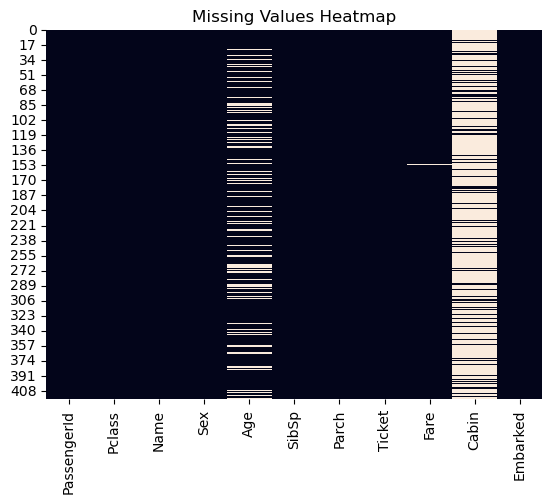

In [23]:
# 4. Missing values overview
print(df.isnull().sum())
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

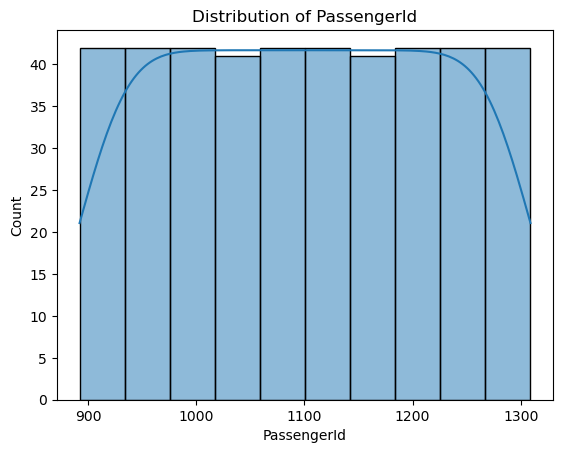

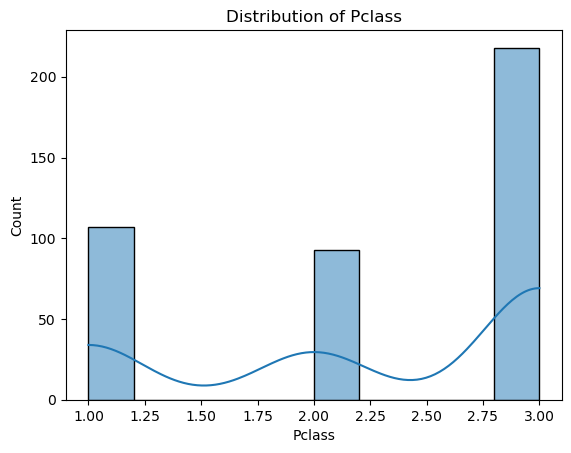

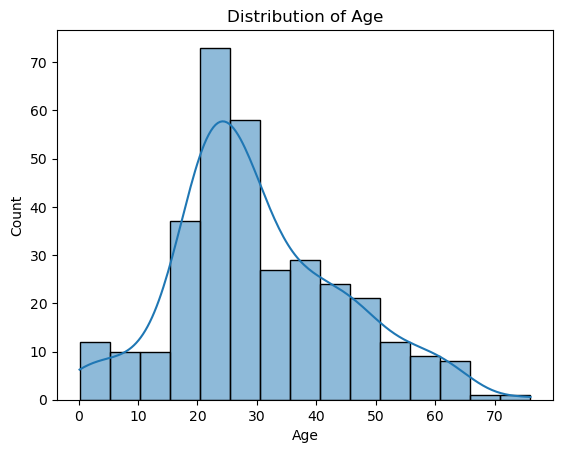

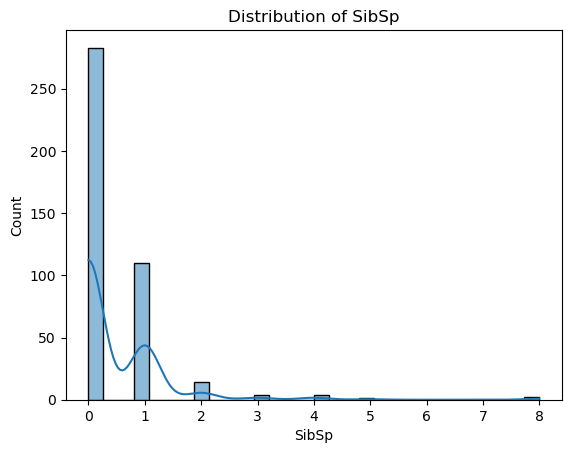

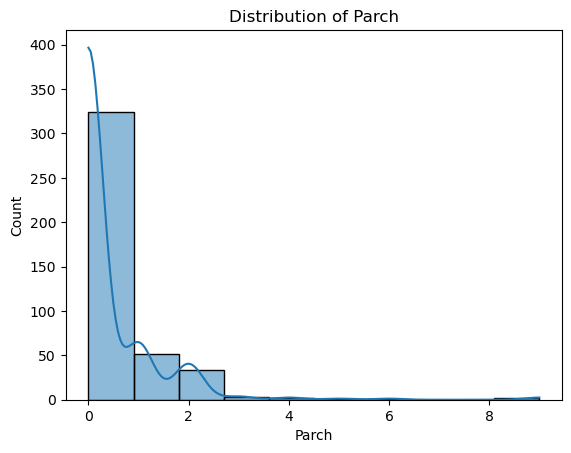

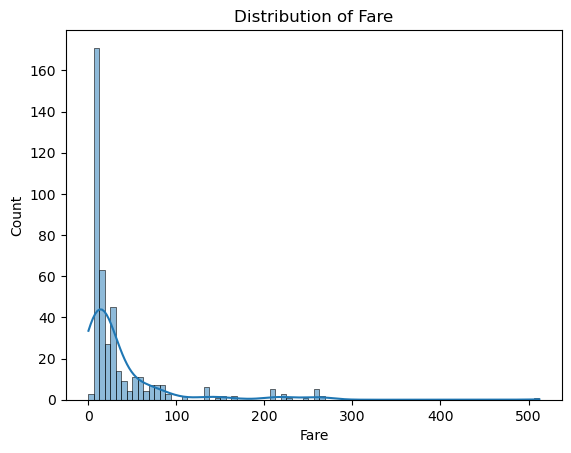

In [24]:
# 5. Univariate Analysis - Numerical Features

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [26]:
# 6. Skewness of numerical features
for col in num_cols:
    print(f"{col} skew: {df[col].skew():.3f}")

PassengerId skew: 0.000
Pclass skew: -0.534
Age skew: 0.457
SibSp skew: 4.168
Parch skew: 4.654
Fare skew: 3.687


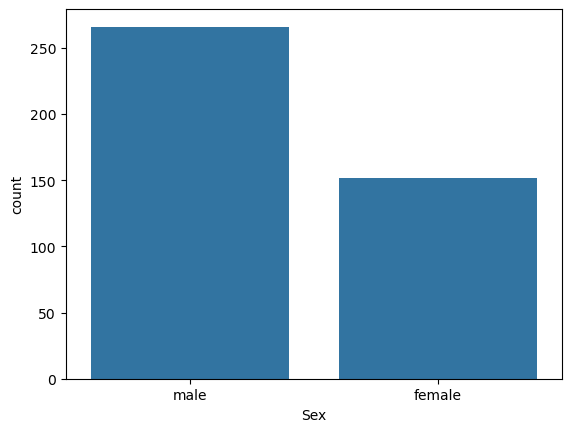

In [ ]:
# 7. Univariate Analysis - Categorical Feature (sex)
sns.countplot(x='Sex', data=df)
plt.show()

In [ ]:
# 8. Encoding Categorical Variable

from sklearn.preprocessing import LabelEncoder

# Label Encoding for Sex
le = LabelEncoder()
df['Sex_label'] = le.fit_transform(df['Sex'])
print( "Sex Classes",le.classes_)
df[['Sex', 'Sex_label']].head()

Sex Classes ['female' 'male']


,Sex,Sex_label
0,male,1
1,female,0
2,male,1
3,male,1
4,female,0


In [34]:
# One-Hot Encoding for species
df_ohe = pd.get_dummies(df['Sex'], prefix='Sex', drop_first=True)
df_ohe.head()

,Sex_male
0,True
1,False
2,True
3,True
4,False


In [35]:
# One-Hot Encoding for species
df_ohe = pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True)
df_ohe.head()

,Embarked_Q,Embarked_S
0,True,False
1,False,True
2,True,False
3,False,True
4,False,True


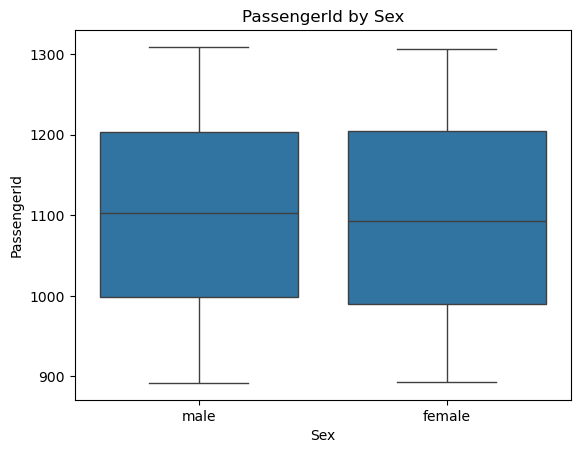

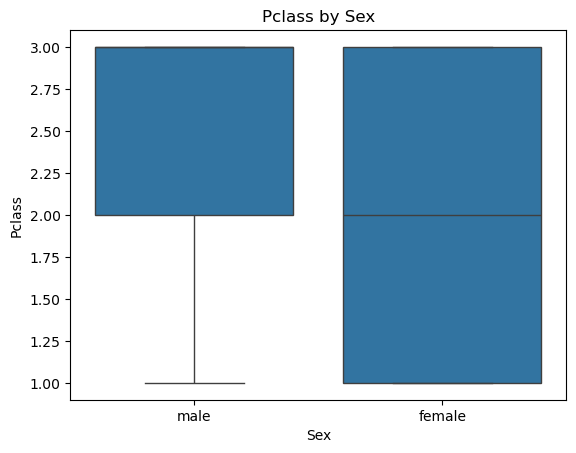

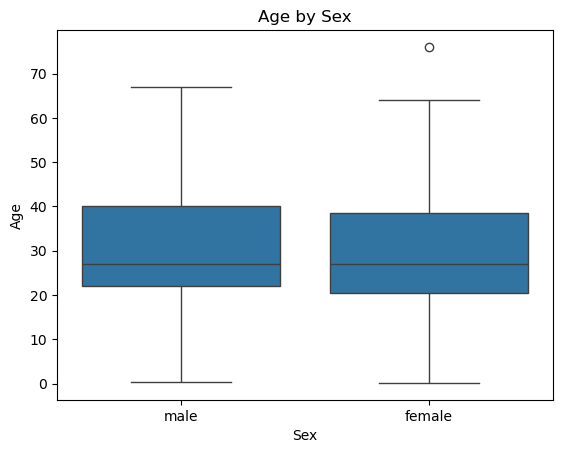

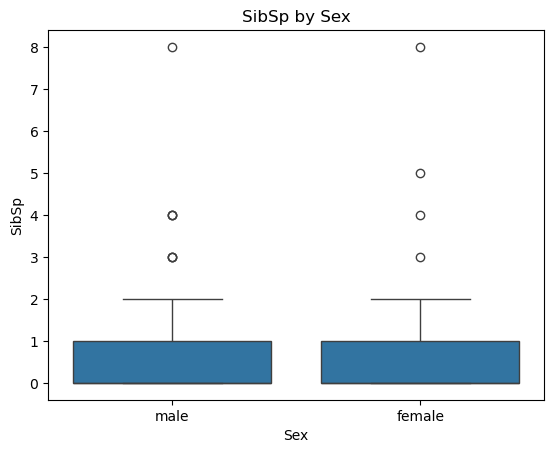

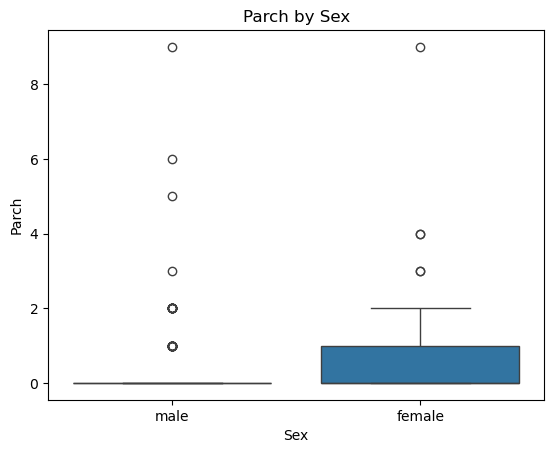

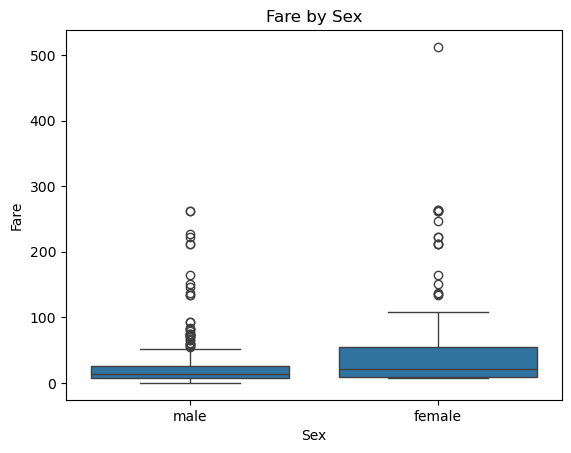

In [36]:
# 9. Bivariate Analysis - Numerical vs Categorical (species)

for col in num_cols:
    plt.figure()
    sns.boxplot(x='Sex', y=col, data=df)
    plt.title(f"{col} by Sex")
    plt.show()

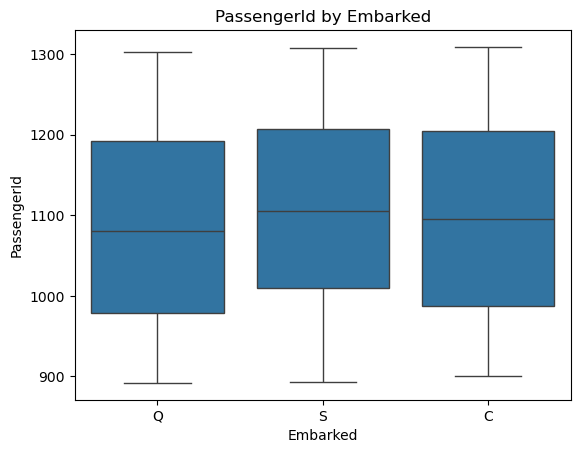

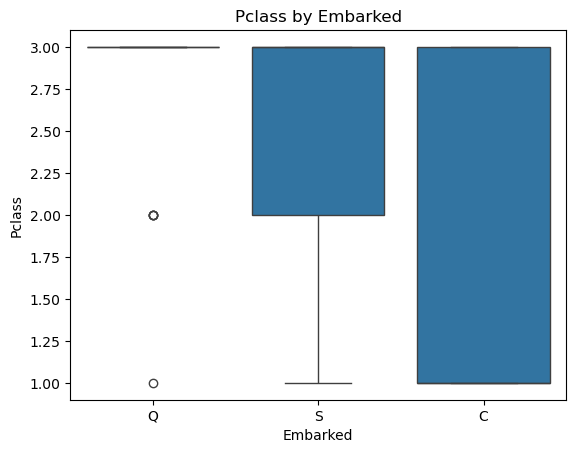

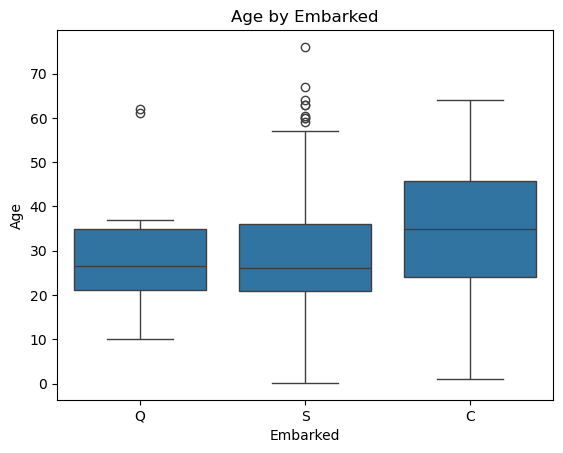

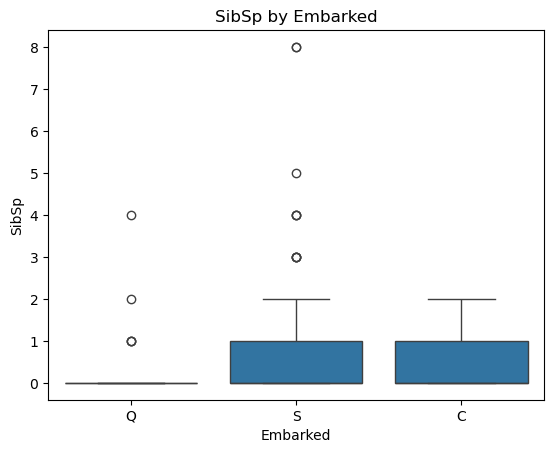

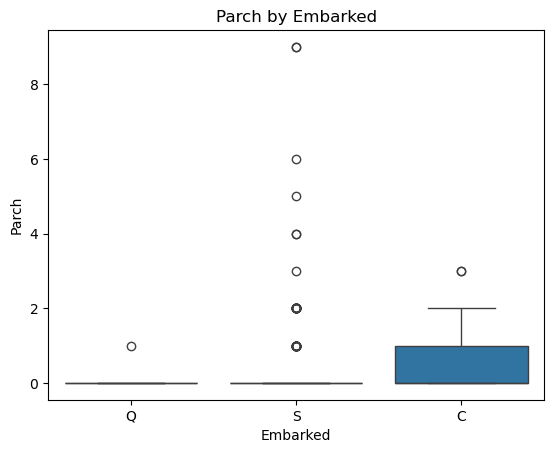

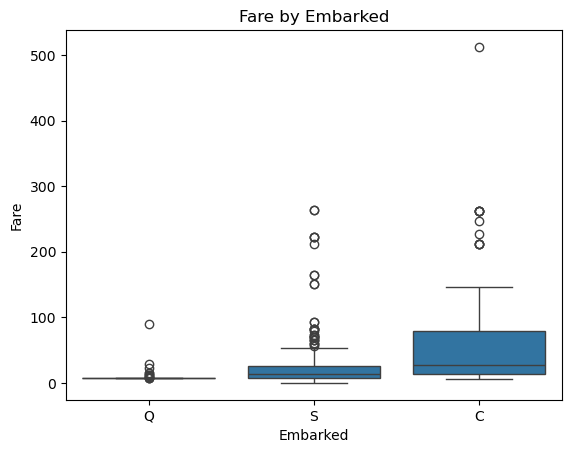

In [37]:
# 9. Bivariate Analysis - Numerical vs Categorical (species)

for col in num_cols:
    plt.figure()
    sns.boxplot(x='Embarked', y=col, data=df)
    plt.title(f"{col} by Embarked")
    plt.show()

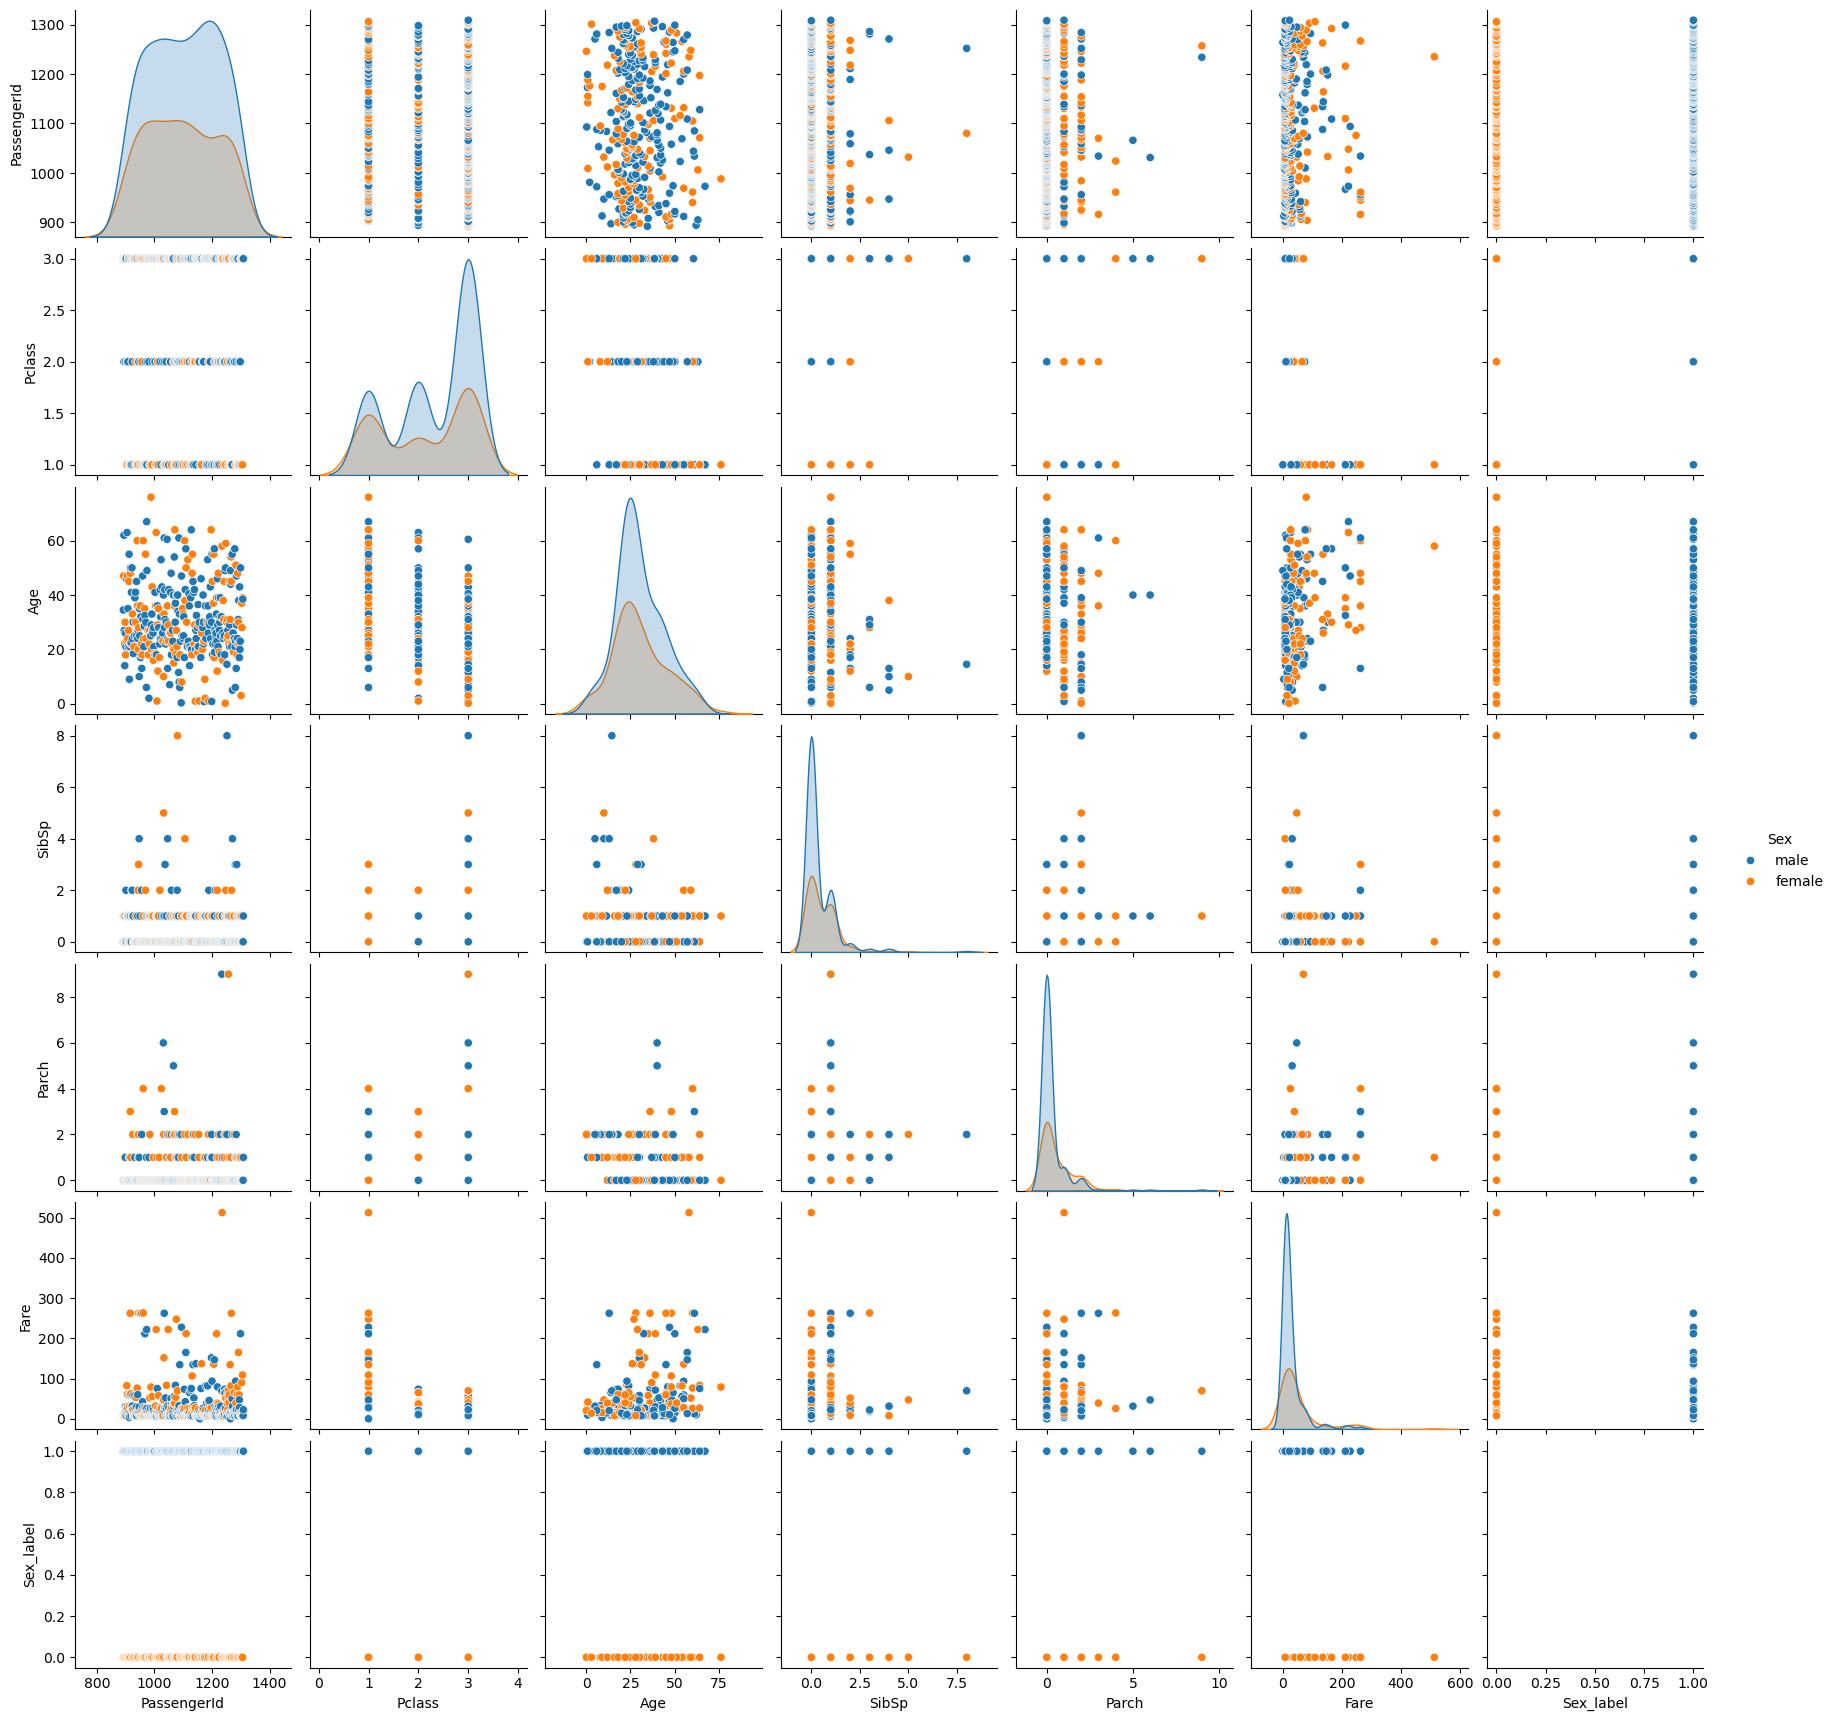

In [39]:
# 10. Multivariate Analysis - Pairplot
sns.pairplot(df, hue='Sex')
plt.show()

             PassengerId    Pclass       Age     SibSp     Parch      Fare  \
PassengerId     1.000000 -0.026751 -0.034102  0.003818  0.043080  0.008211   
Pclass         -0.026751  1.000000 -0.492143  0.001087  0.018721 -0.577147   
Age            -0.034102 -0.492143  1.000000 -0.091587 -0.061249  0.337932   
SibSp           0.003818  0.001087 -0.091587  1.000000  0.306895  0.171539   
Parch           0.043080  0.018721 -0.061249  0.306895  1.000000  0.230046   
Fare            0.008211 -0.577147  0.337932  0.171539  0.230046  1.000000   
Sex_label       0.023245  0.108615  0.000013 -0.099943 -0.159120 -0.191514   

             Sex_label  
PassengerId   0.023245  
Pclass        0.108615  
Age           0.000013  
SibSp        -0.099943  
Parch        -0.159120  
Fare         -0.191514  
Sex_label     1.000000  


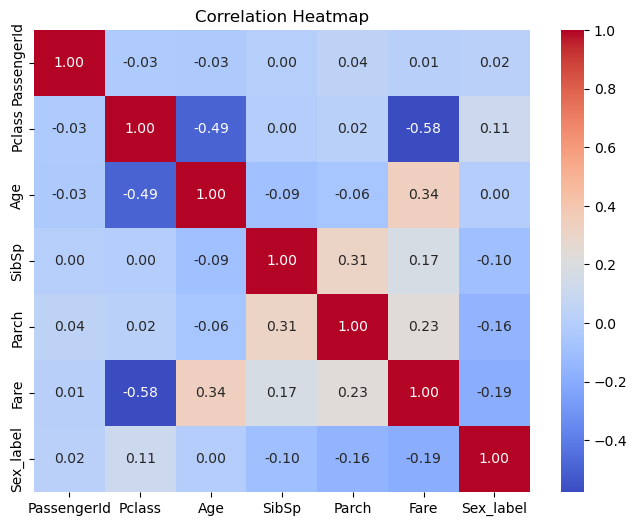

In [40]:
# 11. Correlation and Multivariate Analysis

corr_matrix = df[num_cols.tolist() + ['Sex_label']].corr()
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [41]:
# 12. Outlier Detection using IQR for numerical features

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers

for col in num_cols:
    outliers = detect_outliers_iqr(df[col])
    print(f"\nColumn: {col}")
    print("Number of outliers:", len(outliers))


Column: PassengerId
Number of outliers: 0

Column: Pclass
Number of outliers: 0

Column: Age
Number of outliers: 2

Column: SibSp
Number of outliers: 11

Column: Parch
Number of outliers: 94

Column: Fare
Number of outliers: 55


In [43]:
# 14. Export the cleaned and engineered Iris data
df.to_csv("test_out.csv", index=False)
print("Cleaned and engineered test dataset saved as test_out.csv")

Cleaned and engineered test dataset saved as test_out.csv
